# AI-Powered Sales Forecasting Dashboard

End-to-end workflow: data loading, cleaning, feature engineering, model training,
evaluation, and forecast generation for the Power BI dashboard.


## 1. Imports

In [1]:
import sys
sys.path.insert(0, "../src")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from data_preprocessing import load_data, clean_data
from feature_engineering import create_features, encode_categoricals

sns.set_style("whitegrid")
%matplotlib inline

## 2. Load Raw Data

In [2]:
df = load_data("../data/sales_data.csv")
df.head()

,Date,Store,Product,Region,Promotion,Holiday,Sales
0,2023-01-01,Store_10,Product_D,South,1,1,400.69
1,2023-01-01,Store_5,Product_H,North,1,1,417.71
2,2023-01-01,Store_5,Product_C,North,0,1,325.76
3,2023-01-02,Store_10,Product_E,South,1,0,337.24
4,2023-01-02,Store_3,Product_G,East,0,0,177.49


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       15000 non-null  str    
 1   Store      15000 non-null  str    
 2   Product    15000 non-null  str    
 3   Region     15000 non-null  str    
 4   Promotion  15000 non-null  int64  
 5   Holiday    15000 non-null  int64  
 6   Sales      15000 non-null  float64
dtypes: float64(1), int64(2), str(4)
memory usage: 820.4 KB


,Promotion,Holiday,Sales
count,15000.000000,15000.000000,15000.000000
mean,0.148467,0.019133,241.656917
std,0.355574,0.136998,67.495517
min,0.000000,0.000000,51.190000
25%,0.000000,0.000000,193.760000
50%,0.000000,0.000000,231.390000
75%,0.000000,0.000000,278.730000
max,1.000000,1.000000,605.830000


## 3. Exploratory Data Analysis

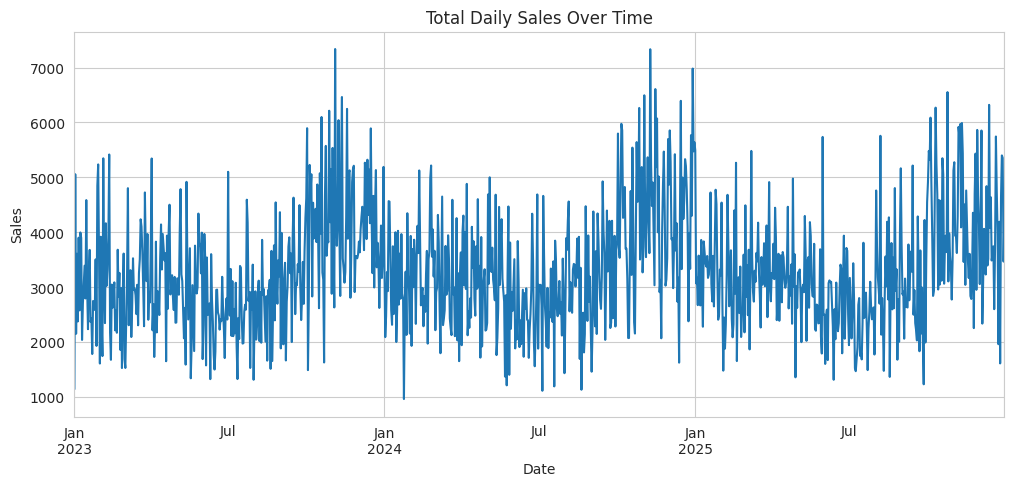

In [4]:
daily_sales = df.copy()
daily_sales["Date"] = pd.to_datetime(daily_sales["Date"])
daily_trend = daily_sales.groupby("Date")["Sales"].sum()

plt.figure(figsize=(12,5))
daily_trend.plot()
plt.title("Total Daily Sales Over Time")
plt.ylabel("Sales")
plt.show()

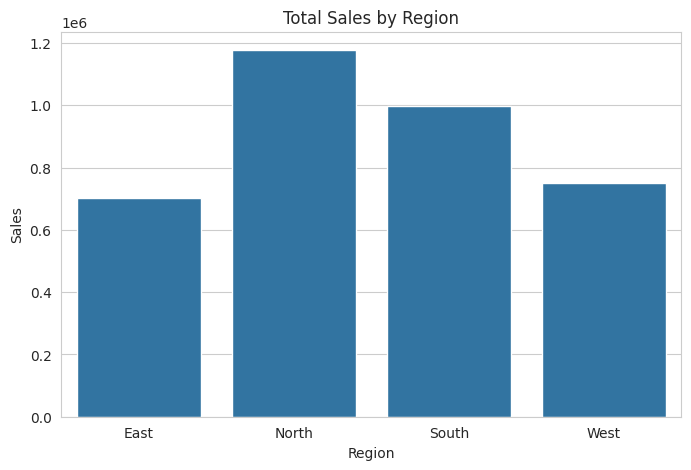

In [5]:
plt.figure(figsize=(8,5))
sns.barplot(x=df.groupby("Region")["Sales"].sum().index,
            y=df.groupby("Region")["Sales"].sum().values)
plt.title("Total Sales by Region")
plt.ylabel("Sales")
plt.show()

## 4. Data Cleaning

In [6]:
df_clean = clean_data(df)
df_clean.isna().sum()

Date         0
Store        0
Product      0
Region       0
Promotion    0
Holiday      0
Sales        0
dtype: int64

## 5. Feature Engineering

In [7]:
df_feat = create_features(df_clean)
df_encoded = encode_categoricals(df_feat)
df_encoded.to_csv("../data/processed_sales.csv", index=False)
df_encoded.head()

,Date,Promotion,Holiday,Sales,Year,Month,Day,Weekday,WeekOfYear,IsWeekend,...,Product_Product_C,Product_Product_D,Product_Product_E,Product_Product_F,Product_Product_G,Product_Product_H,Region_East,Region_North,Region_South,Region_West
0,2023-01-01,1,1,400.69,2023,1,1,6,52,1,...,False,True,False,False,False,False,False,False,True,False
1,2023-01-01,1,1,417.71,2023,1,1,6,52,1,...,False,False,False,False,False,True,False,True,False,False
2,2023-01-01,0,1,325.76,2023,1,1,6,52,1,...,True,False,False,False,False,False,False,True,False,False
3,2023-01-02,1,0,337.24,2023,1,2,0,1,0,...,False,False,True,False,False,False,False,False,True,False
4,2023-01-02,0,0,177.49,2023,1,2,0,1,0,...,False,False,False,False,True,False,True,False,False,False


## 6. Train / Test Split

In [8]:
X = df_encoded.drop(columns=["Sales", "Date"])
y = df_encoded["Sales"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((12000, 30), (3000, 30))

## 7. Model Training — Random Forest Regressor

In [9]:
model = RandomForestRegressor(
    n_estimators=80,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",80
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

## 8. Model Evaluation

In [10]:
preds = model.predict(X_test)

mae = mean_absolute_error(y_test, preds)
rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R2:   {r2:.4f}")

MAE:  31.99
RMSE: 41.21
R2:   0.6319


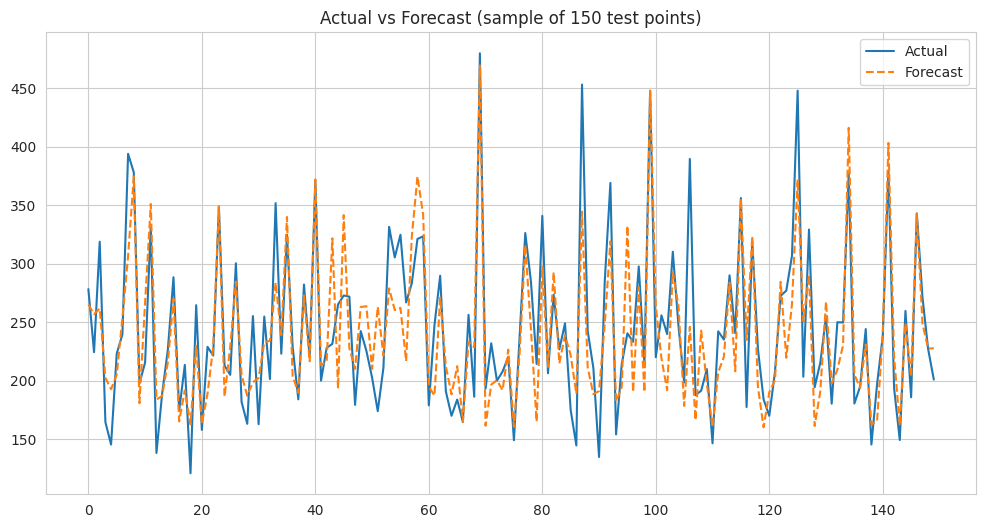

In [11]:
plt.figure(figsize=(12,6))
plt.plot(y_test.values[:150], label="Actual")
plt.plot(preds[:150], label="Forecast", linestyle="--")
plt.legend()
plt.title("Actual vs Forecast (sample of 150 test points)")
plt.show()

## 9. Feature Importance

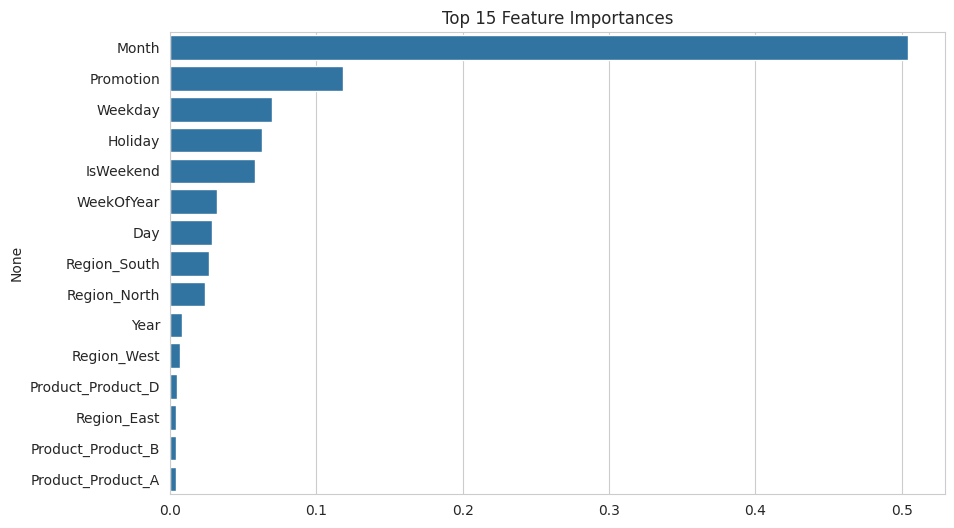

In [12]:
importances = pd.Series(model.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10,6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Top 15 Feature Importances")
plt.show()

## 10. Save Model & Generate Forecast Output

In [13]:
import joblib
joblib.dump(model, "../models/sales_forecast_model.pkl")

full_preds = model.predict(X)
df_encoded["Forecast"] = full_preds.round(2)
df_encoded[["Date", "Sales", "Forecast"]].to_csv("../outputs/predictions.csv", index=False)

print("Model and predictions saved.")

Model and predictions saved.


## 11. Next Steps

- Import `outputs/predictions.csv` into Power BI to build the forecast-vs-actual dashboard.
- Experiment with XGBoost / Prophet for potentially better seasonal accuracy.
- Deploy as a Streamlit app for interactive what-if forecasting.
